In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import*
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [5]:
df=pd.read_csv(r"C:\Users\ANJALI VERMA\OneDrive\Desktop\E-Commerce Orders.csv")

In [6]:
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [8]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [10]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [11]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [12]:
df.dtypes

OrderID             object
Date                object
CustomerID          object
Product             object
Quantity             int64
UnitPrice          float64
ShippingAddress     object
PaymentMethod       object
OrderStatus         object
TrackingNumber      object
ItemsInCart          int64
CouponCode          object
ReferralSource      object
TotalPrice         float64
dtype: object

In [13]:
columns=['OrderID','CustomerID','Product','ShippingAddress','PaymentMethod','OrderStatus','TrackingNumber','CouponCode','ReferralSource']
for col in columns:
    df[col]=df[col].astype('category')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   category      
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   category      
 3   Product          1200 non-null   category      
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   category      
 7   PaymentMethod    1200 non-null   category      
 8   OrderStatus      1200 non-null   category      
 9   TrackingNumber   1200 non-null   category      
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    category      
 12  ReferralSource   1200 non-null   category      
 13  TotalPrice       1200 non-null   float64       
dtypes: category(9), datetime64[ns](1), float

In [16]:
df['Date']=pd.to_datetime(df['Date'])

In [18]:
df['Month']=df['Date'].dt.month
df['Day']=df['Date'].dt.day

In [20]:
df.shape

(1200, 16)

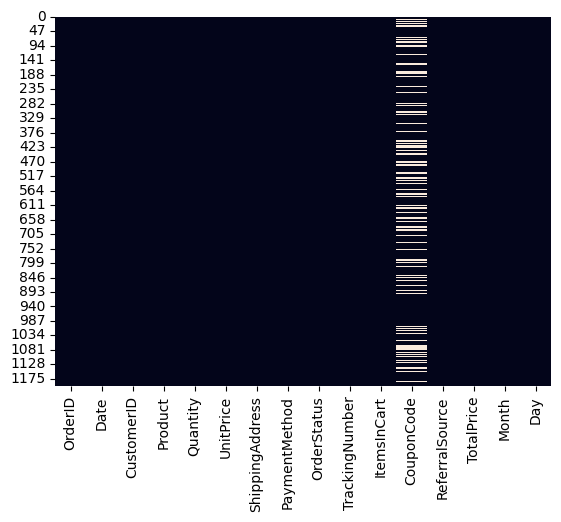

In [ ]:
# Missing values visualization  
sns.heatmap(df.isnull(),cbar=False)
plt.show()

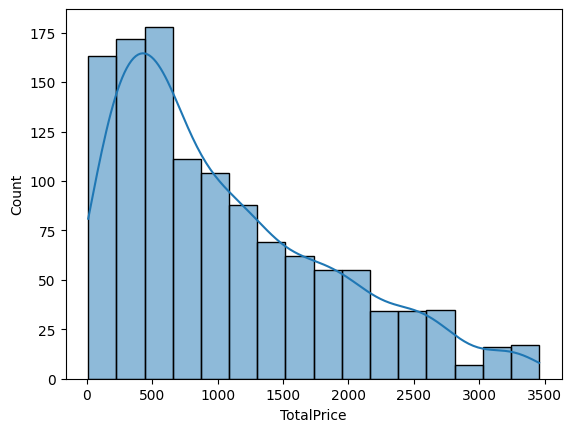

In [ ]:
# Distribution of numerical features 
sns.histplot(df['TotalPrice'],kde=True)
plt.show()

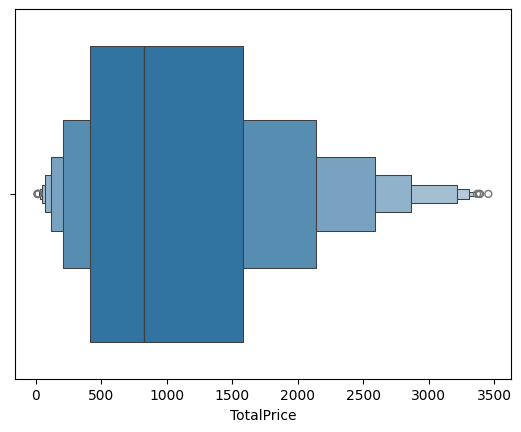

In [ ]:
# check outliers exist in totalprice 
sns.boxenplot(x=df['TotalPrice'])
plt.show()

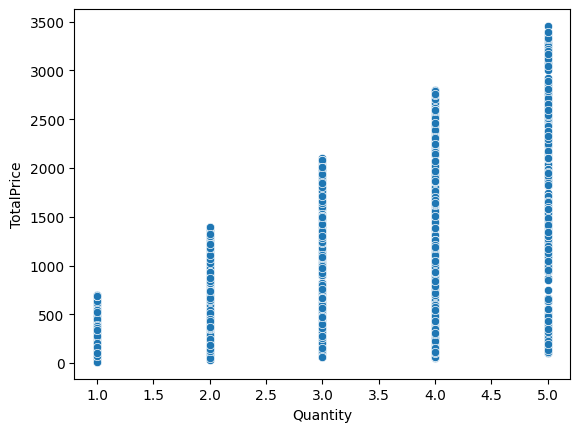

In [31]:
# relationship between features 
sns.scatterplot(x='Quantity',y='TotalPrice',data=df)
plt.show()

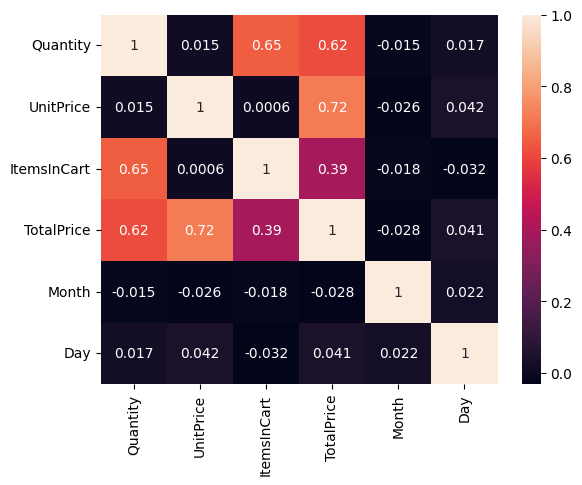

In [42]:
# correlation (detect multicollinearity)
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)
plt.show()

In [46]:
df['sqrt_TotalPrice']=np.sqrt(df['TotalPrice'])

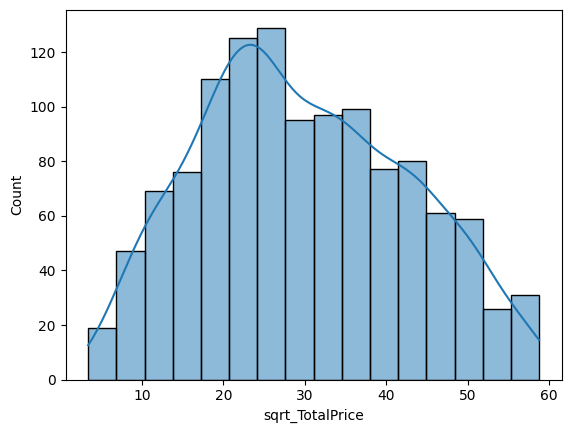

In [50]:
sns.histplot(df['sqrt_TotalPrice'],kde=True)
plt.show()

In [53]:
x=df.drop(['TotalPrice','sqrt_TotalPrice'],axis=1,)
y=df['sqrt_TotalPrice']

In [56]:
X_trian, X_test, Y_train, Y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [57]:
print(X_trian.shape,X_test.shape,Y_train.shape,Y_test.shape)

(960, 16) (240, 16) (960,) (240,)


In [58]:
X_trian

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,Month,Day,Log_TotalPrice
331,ORD200331,2023-04-15,C78724,Printer,3,422.13,187 Main St,Online,Delivered,TRK25703134,7,SAVE10,Facebook,4,15,7.143926
409,ORD200409,2023-06-28,C45187,Desk,5,84.13,767 Main St,Online,Delivered,TRK12320793,9,SAVE10,Google,6,28,6.041801
76,ORD200076,2024-03-31,C58638,Laptop,4,382.88,239 Main St,Cash,Cancelled,TRK38224871,6,WINTER15,Email,3,31,7.334016
868,ORD200868,2024-06-29,C70452,Monitor,4,316.32,309 Main St,Debit Card,Delivered,TRK42985882,7,NaN,Facebook,6,29,7.143049
138,ORD200138,2023-12-21,C21905,Tablet,1,298.06,478 Main St,Debit Card,Pending,TRK31863841,3,WINTER15,Google,12,21,5.697295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044,ORD201044,2025-06-22,C63018,Printer,1,38.49,215 Main St,Credit Card,Delivered,TRK52335337,4,FREESHIP,Referral,6,22,3.650398
1095,ORD201095,2024-04-23,C33051,Phone,2,441.54,397 Main St,Online,Delivered,TRK92929755,2,SAVE10,Email,4,23,6.783416
1130,ORD201130,2025-02-16,C24347,Laptop,2,323.45,533 Main St,Credit Card,Returned,TRK27233265,5,FREESHIP,Instagram,2,16,6.472192
860,ORD200860,2024-01-23,C69542,Printer,1,422.54,876 Main St,Cash,Delivered,TRK20746505,1,SAVE10,Google,1,23,6.046284


In [59]:
X_test

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,Month,Day,Log_TotalPrice
1178,ORD201178,2024-09-08,C65107,Monitor,1,70.24,456 Main St,Credit Card,Cancelled,TRK10261578,4,FREESHIP,Google,9,8,4.251918
865,ORD200865,2023-04-30,C72241,Monitor,4,677.37,156 Main St,Cash,Pending,TRK76270481,8,SAVE10,Google,4,30,7.904512
101,ORD200101,2023-11-25,C15283,Printer,1,381.02,152 Main St,Cash,Shipped,TRK19286291,6,NaN,Google,11,25,5.942852
439,ORD200439,2024-09-08,C91155,Tablet,1,146.32,321 Main St,Online,Shipped,TRK36260319,4,WINTER15,Facebook,9,8,4.985796
58,ORD200058,2023-01-15,C60190,Phone,4,474.69,202 Main St,Gift Card,Cancelled,TRK70857868,6,SAVE10,Google,1,15,7.548956
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
382,ORD200382,2025-01-30,C26718,Printer,4,263.09,272 Main St,Debit Card,Shipped,TRK91702525,8,SAVE10,Google,1,30,6.958791
867,ORD200867,2024-05-26,C53252,Printer,4,142.58,351 Main St,Cash,Delivered,TRK65831261,4,FREESHIP,Facebook,5,26,6.346198
542,ORD200542,2023-11-14,C49726,Tablet,1,17.98,934 Main St,Cash,Cancelled,TRK20739460,6,FREESHIP,Email,11,14,2.889260
1193,ORD201193,2025-06-16,C45104,Tablet,1,687.89,348 Main St,Cash,Returned,TRK38559816,1,FREESHIP,Email,6,16,6.533629


In [60]:
Y_train

331     35.586374
409     20.509754
76      39.134639
868     35.570775
138     17.264414
          ...    
1044     6.204031
1095    29.716662
1130    25.434229
860     20.555778
1126    30.830991
Name: sqrt_TotalPrice, Length: 960, dtype: float64

In [61]:
Y_test

1178     8.380931
865     52.052666
101     19.519734
439     12.096280
58      43.574763
          ...    
382     32.440099
867     23.881373
542      4.240283
1193    26.227657
874     31.269794
Name: sqrt_TotalPrice, Length: 240, dtype: float64